# Pipeline Completo de NER em Português

## Objetivo

Este notebook implementa um **pipeline completo de Reconhecimento de Entidades Nomeadas (NER)** em textos em português, cobrindo quatro abordagens progressivamente mais sofisticadas:

1. **Baseline Regex** — regras explícitas com expressões regulares
2. **BoW / TF-IDF** — representações esparsas de frequência de termos
3. **N-gramas + Regressão Logística** — captura de dependências locais entre tokens
4. **Fine-tuning BERT** — modelo pré-treinado `neuralmind/bert-base-portuguese-cased` com compreensão contextual

## Dataset

- **Fonte:** Artigos da Wikipedia em português
- **Tamanho:** 10.000 amostras carregadas via biblioteca `datasets`
- **Seed:** 42 (reprodutibilidade)

## Entidades Reconhecidas

| Rótulo | Significado |
|--------|-------------|
| `B-PER` / `I-PER` | Pessoa |
| `B-LOC` / `I-LOC` | Localização |
| `B-ORG` / `I-ORG` | Organização |
| `O` | Fora de entidade |

In [1]:
# Instalação de todas as dependências necessárias para o pipeline
!pip install -q transformers seqeval torch wikisets datasets accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## Configuração Global

Todos os parâmetros configuráveis do pipeline estão centralizados no dicionário `CONFIG`:

| Parâmetro | Valor | Descrição |
|-----------|-------|-----------|
| `TAMANHO_DATASET` | 10000 | Número de artigos carregados do wikisets |
| `SEED` | 42 | Semente para reprodutibilidade |
| `PROPORCAO_TESTE` | 0.2 | 20% dos dados reservados para teste |
| `EPOCAS_BERT` | 3 | Número de épocas de fine-tuning do BERT |
| `LR_BERT` | 2e-5 | Taxa de aprendizado do BERT |
| `BATCH_SIZE` | 16 | Tamanho do batch para treino e inferência |
| `MAX_LEN` | 128 | Comprimento máximo de sequência (tokens BERT) |
| `MODELO_BERT` | `neuralmind/bert-base-portuguese-cased` | Modelo pré-treinado base |

In [2]:
# Importações necessárias
import random
import numpy as np

# Dicionário central de configuração do pipeline
CONFIG = {
    "TAMANHO_DATASET": 10000,
    "SEED": 42,
    "PROPORCAO_TESTE": 0.2,
    "EPOCAS_BERT": 3,
    "LR_BERT": 2e-5,
    "BATCH_SIZE": 16,
    "MAX_LEN": 128,
    "MODELO_BERT": "neuralmind/bert-base-portuguese-cased",
    "STRIDE": 64
}

# Mapeamento de rótulos BIO para IDs numéricos
LABEL2ID = {"O": 0, "B-PER": 1, "I-PER": 2, "B-LOC": 3, "I-LOC": 4, "B-ORG": 5, "I-ORG": 6}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS = len(LABEL2ID)

# Fixar seeds para reprodutibilidade
random.seed(CONFIG["SEED"])
np.random.seed(CONFIG["SEED"])

print("Configuração carregada:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")
print(f"\nNúmero de rótulos BIO: {NUM_LABELS}")
print(f"Rótulos: {list(LABEL2ID.keys())}")


Configuração carregada:
  TAMANHO_DATASET: 10000
  SEED: 42
  PROPORCAO_TESTE: 0.2
  EPOCAS_BERT: 3
  LR_BERT: 2e-05
  BATCH_SIZE: 16
  MAX_LEN: 128
  MODELO_BERT: neuralmind/bert-base-portuguese-cased
  STRIDE: 64

Número de rótulos BIO: 7
Rótulos: ['O', 'B-PER', 'I-PER', 'B-LOC', 'I-LOC', 'B-ORG', 'I-ORG']


## Carregamento do Dataset

Utilizamos a biblioteca `datasets` em `omarkamali/wikipedia-monthly` para carregar artigos da Wikipedia em português.
A função `carregar_dataset` encapsula o carregamento e converte o resultado em um DataFrame pandas.

- **Amostras:** 10.000 artigos com `seed=42`
- **Tratamento de erros:** mensagem descritiva em caso de falha no carregamento

In [3]:
import pandas as pd
df_gabarito = pd.read_parquet("dataset_labels.parquet")

In [4]:
df_gabarito.head()

,labels
0,"[O, B-ORG, I-ORG, I-ORG, B-ORG, O, O, O, O, B-..."
1,"[B-PER, I-PER, I-PER, I-PER, O, O, O, B-PER, B..."
2,"[O, B-LOC, I-LOC, O, B-PER, I-PER, O, B-LOC, I..."
3,"[O, B-MISC, I-MISC, I-MISC, O, B-MISC, I-MISC,..."
4,"[O, O, O, B-PER, I-PER, O, B-PER, B-PER, I-PER..."


In [5]:
import pandas as pd

def carregar_dataset(tamanho: int, seed: int) -> pd.DataFrame:
    """
    Carrega artigos da Wikipedia em português via datasets.

    Args:
        tamanho: número de amostras a carregar
        seed: semente para reprodutibilidade

    Returns:
        DataFrame pandas com coluna 'text' e demais metadados
    """
    try:
        from datasets import load_dataset

        # Carregar dataset Wikipedia em português do Hugging Face
        print(f"Carregando {tamanho} artigos da Wikipedia em português...")

        # Usar o dataset omarkamali/wikipedia-monthly com configuração para português
        dataset = load_dataset(
            "omarkamali/wikipedia-monthly",
            "latest.pt",  # Configuração para português
            split="train",
            streaming=True
        )

        # Coletar as primeiras 'tamanho' amostras do stream
        registros = []
        for i, exemplo in enumerate(dataset):
            if i >= tamanho:
                break
            registros.append(exemplo)

        # Converter para DataFrame pandas
        df = pd.DataFrame(registros)

        # Garantir que a coluna 'text' existe
        colunas_texto = ['text', 'content', 'article', 'body']
        for col in colunas_texto:
            if col in df.columns and col != 'text':
                df = df.rename(columns={col: 'text'})
                break

        if 'text' not in df.columns:
            # Usar a primeira coluna de string como texto
            str_cols = [c for c in df.columns if df[c].dtype == object]
            if str_cols:
                df = df.rename(columns={str_cols[0]: 'text'})
            else:
                raise ValueError("Dataset não contém coluna de texto identificável.")

        # Remover linhas com texto nulo ou vazio
        df = df.dropna(subset=['text'])
        df = df[df['text'].str.strip() != '']
        df = df.head(tamanho).reset_index(drop=True)

        # Embaralhar com seed para reprodutibilidade
        df = df.sample(frac=1, random_state=seed).reset_index(drop=True)

        print(f"Dataset carregado com sucesso: {len(df)} amostras")
        print(f"Colunas disponíveis: {list(df.columns)}")
        return df

    except ImportError as e:
        raise ImportError(
            f"Erro ao importar datasets: {e}. "
            "Execute '!pip install datasets' e reinicie o kernel."
        )
    except Exception as e:
        raise RuntimeError(
            f"Falha ao carregar o dataset Wikipedia PT: {e}. "
            "Verifique a conexão com a internet e a disponibilidade do dataset."
        )


# Carregar o dataset
df = carregar_dataset(CONFIG["TAMANHO_DATASET"], CONFIG["SEED"])
df.head()

Carregando 10000 artigos da Wikipedia em português...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/1425 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/234 [00:00<?, ?it/s]

Dataset carregado com sucesso: 10000 amostras
Colunas disponíveis: ['id', 'url', 'title', 'text']


,id,url,title,text
0,12226,https://pt.wikipedia.org/wiki/União_Democrata-...,União Democrata-Cristã,"A União Democrata-Cristã da Alemanha (, CDU), ..."
1,9594,https://pt.wikipedia.org/wiki/Sivuca,Sivuca,"Severino Dias de Oliveira, mais conhecido como..."
2,4812,https://pt.wikipedia.org/wiki/Samoa_Americana,Samoa Americana,"A Samoa Americana (, ; , ; também Amelika Sāmo..."
3,9715,https://pt.wikipedia.org/wiki/Guerra_Civil_Ing...,Guerra Civil Inglesa,"A Guerra Civil Inglesa, ou Grande Rebelião, fo..."
4,9323,https://pt.wikipedia.org/wiki/18_de_junho,18 de junho,Eventos históricos\n 618 — Li Yuan torna-se o ...


## Pré-processamento dos Textos

A função `preprocessar_texto` realiza a tokenização e normalização de cada artigo:

1. **Tokenização:** divide o texto em tokens usando `re.findall` (palavras e números)
2. **Lowercase:** converte todos os tokens para letras minúsculas
3. **Filtragem:** remove tokens compostos exclusivamente por caracteres não-alfanuméricos
4. **Robustez:** retorna lista vazia para entrada nula ou vazia, sem lançar exceção

In [6]:
!pip install -U spacy

In [7]:
!python -m spacy download pt_core_news_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 3.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [8]:
import spacy

nlp = spacy.load("pt_core_news_lg")

In [9]:
docs = (nlp.make_doc(texto) for texto in df["text"].fillna("").astype(str))

df["tokens"] = [
    [token.text for token in doc]
    for doc in docs
]

In [10]:
import re

def filtrar_tokens_regex_like(tokens):
    return [token for token in tokens if re.fullmatch(r"[\w']+", token, re.UNICODE)]

df["tokens"] = df["tokens"].apply(filtrar_tokens_regex_like)


In [11]:
df["labels"] = df_gabarito["labels"]

In [12]:
df.head()

,id,url,title,text,tokens,labels
0,12226,https://pt.wikipedia.org/wiki/União_Democrata-...,União Democrata-Cristã,"A União Democrata-Cristã da Alemanha (, CDU), ...","[A, União, da, Alemanha, CDU, também, simplesm...","[O, B-ORG, I-ORG, I-ORG, B-ORG, O, O, O, O, B-..."
1,9594,https://pt.wikipedia.org/wiki/Sivuca,Sivuca,"Severino Dias de Oliveira, mais conhecido como...","[Severino, Dias, de, Oliveira, mais, conhecido...","[B-PER, I-PER, I-PER, I-PER, O, O, O, B-PER, B..."
2,4812,https://pt.wikipedia.org/wiki/Samoa_Americana,Samoa Americana,"A Samoa Americana (, ; , ; também Amelika Sāmo...","[A, Samoa, Americana, também, Amelika, Sāmoa, ...","[O, B-LOC, I-LOC, O, B-PER, I-PER, O, B-LOC, I..."
3,9715,https://pt.wikipedia.org/wiki/Guerra_Civil_Ing...,Guerra Civil Inglesa,"A Guerra Civil Inglesa, ou Grande Rebelião, fo...","[A, Guerra, Civil, Inglesa, ou, Grande, Rebeli...","[O, B-MISC, I-MISC, I-MISC, O, B-MISC, I-MISC,..."
4,9323,https://pt.wikipedia.org/wiki/18_de_junho,18 de junho,Eventos históricos\n 618 — Li Yuan torna-se o ...,"[Eventos, históricos, 618, Li, Yuan, o, Impera...","[O, O, O, B-PER, I-PER, O, B-PER, B-PER, I-PER..."


In [13]:
def remover_misc(labels):
    return [
        "O" if label in ["B-MISC", "I-MISC"] else label
        for label in labels
    ]

df["labels"] = df["labels"].apply(remover_misc)

In [14]:
# Importações necessárias
from sklearn.model_selection import train_test_split

# Dividir o dataset em treino (80%) e teste (20%)
df_treino, df_teste = train_test_split(
    df,
    test_size=CONFIG["PROPORCAO_TESTE"],
    random_state=CONFIG["SEED"],
)

# Resetar índices
df_treino = df_treino.reset_index(drop=True)
df_teste = df_teste.reset_index(drop=True)

print(f"Divisão treino/teste concluída:")
print(f"  Treino: {len(df_treino)} amostras ({100*(1-CONFIG['PROPORCAO_TESTE']):.0f}%)")
print(f"  Teste:  {len(df_teste)} amostras ({100*CONFIG['PROPORCAO_TESTE']:.0f}%)")
print(f"\nColunas disponíveis: {list(df_treino.columns)}")


Divisão treino/teste concluída:
  Treino: 8000 amostras (80%)
  Teste:  2000 amostras (20%)

Colunas disponíveis: ['id', 'url', 'title', 'text', 'tokens', 'labels']


In [15]:
# DIAGNÓSTICO: Verificar distribuição de rótulos
from collections import Counter

# Contar rótulos no conjunto de treino
todos_labels_treino = [lab for labels in df_treino['labels'] for lab in labels]
contagem_treino = Counter(todos_labels_treino)

print("DISTRIBUIÇÃO DE RÓTULOS NO CONJUNTO DE TREINO")
print("="*50)
total = sum(contagem_treino.values())
for label, count in contagem_treino.most_common():
    pct = (count / total) * 100
    print(f"{label:10s}: {count:6d} ({pct:5.2f}%)")

# Verificar se há entidades suficientes
entidades = sum(count for label, count in contagem_treino.items() if label != 'O')
pct_entidades = (entidades / total) * 100

print(f"\nTotal de tokens: {total:,}")
print(f"Tokens com entidades: {entidades:,} ({pct_entidades:.2f}%)")
print(f"Tokens 'O' (sem entidade): {contagem_treino['O']:,} ({100-pct_entidades:.2f}%)")

if pct_entidades < 5:
    print("\n⚠️ PROBLEMA DETECTADO: Muito poucas entidades anotadas!")
    print("   A função de anotação BIO está muito conservadora.")
    print("   Sugestões:")
    print("   1. Melhorar os padrões regex para detectar mais entidades")
    print("   2. Usar dataset já anotado (ex: HAREM corpus)")
    print("   3. Aumentar tamanho do dataset para ter mais exemplos")


DISTRIBUIÇÃO DE RÓTULOS NO CONJUNTO DE TREINO
O         : 10937183 (85.04%)
B-LOC     : 518783 ( 4.03%)
I-LOC     : 446468 ( 3.47%)
I-PER     : 338330 ( 2.63%)
B-PER     : 334181 ( 2.60%)
I-ORG     : 170857 ( 1.33%)
B-ORG     : 115149 ( 0.90%)

Total de tokens: 12,860,951
Tokens com entidades: 1,923,768 (14.96%)
Tokens 'O' (sem entidade): 10,937,183 (85.04%)


## Abordagem 1: Baseline com Expressões Regulares

A baseline mais simples para NER usa **expressões regulares** para identificar padrões textuais associados a entidades nomeadas.

### Padrões Utilizados

- **PER:** sequências de 2–4 palavras capitalizadas (ex: `João Silva`, `Maria de Fátima`)
- **LOC:** lista estática de países/cidades + padrão geográfico
- **ORG:** sufixos organizacionais como `S.A.`, `Ltda.`, `Ministério`, `Universidade`

### Processo

1. Aplicar padrões regex ao texto original
2. Converter matches para formato BIO alinhado com os tokens
3. Avaliar com seqeval sobre o conjunto de teste

Tentativa Alternativo (com piora)

Principais Regras:

Siglas: Identifica sequências em maiúsculas (ex: UFPB, ONU) como ORG.

Prefixos e Conectivos: Captura nomes longos iniciados por palavras-chave (Universidade, Tribunal) incluindo conectivos (de, da, e).

Gatilhos Contextuais:

LOC: Palavras capitalizadas após preposições de lugar (em, no, para).

PER: Palavras capitalizadas após títulos ou profissões (Sr., Dr., músico).

Filtro de Sentença: Ignora maiúsculas em início de frase (após . ! ?) para reduzir falsos positivos com substantivos comuns.

Integridade BIO: Garante que todo rótulo I- seja precedido por um B-, corrigindo a falha estrutural dos N-gramas.

In [51]:
import re

def ner_regex_adaptado(texto: str) -> list:
    if not texto or not isinstance(texto, str):
        return []

    # Tokenização melhorada: preserva pontuação como tokens separados
    # Isso é vital para saber se uma palavra maiúscula é início de frase ou nome próprio
    tokens_originais = re.findall(r"\w+|[.,!?;]", texto, re.UNICODE)
    if not tokens_originais:
        return []

    rotulos = ["O"] * len(tokens_originais)

    # 1. PADRÃO SIGLAS (Geralmente ORG ou LOC)
    # Pega palavras com 2+ letras maiúsculas: UFPB, ONU, EUA
    for i, tok in enumerate(tokens_originais):
        if re.fullmatch(r"[A-Z]{2,}", tok):
            rotulos[i] = "B-ORG" # Simplificação: siglas costumam ser ORG ou LOC

    # 2. PADRÃO ORGANIZAÇÕES (Prefixos + Continuidade)
    prefixos_org = r"^(Universidade|Ministério|Instituto|Fundação|Banco|Hospital|Escola|Faculdade|Tribunal|Câmara|Senado|Prefeitura|Associação)$"
    conectivos = ["de", "da", "do", "dos", "das", "e"]

    i = 0
    while i < len(tokens_originais):
        if re.fullmatch(prefixos_org, tokens_originais[i], re.IGNORECASE):
            rotulos[i] = "B-ORG"
            j = i + 1
            # Engole palavras capitalizadas ou conectivos que venham depois
            while j < len(tokens_originais):
                prox = tokens_originais[j]
                if prox[0].isupper() or prox.lower() in conectivos:
                    rotulos[j] = "I-ORG"
                    j += 1
                else:
                    break
            i = j
        else:
            i += 1

    # 3. PADRÃO PESSOAS E LOCAIS (Sequências de Capitalizadas com Contexto)
    # Gatilhos para Pessoas
    gatilhos_per = ["doutor", "dr.", "prof.", "senhor", "sr.", "músico", "escritor", "presidente"]
    # Gatilhos para Locais
    gatilhos_loc = ["em", "no", "na", "para", "de", "cidade", "estado", "país"]

    i = 0
    while i < len(tokens_originais):
        if rotulos[i] != "O": # Pula se já foi marcado (ex: pela regra de ORG)
            i += 1
            continue

        tok = tokens_originais[i]

        # Só olhamos palavras capitalizadas que NÃO estão no início absoluto da frase
        if tok and tok[0].isupper() and i > 0:
            tok_ant = tokens_originais[i-1].lower()

            # Se não for fim de frase (.), é um forte candidato
            if tok_ant not in [".", "!", "?"]:

                # Regra de decisão de Tag baseada no gatilho anterior
                tag_tipo = "PER"
                if tok_ant in gatilhos_loc:
                    tag_tipo = "LOC"
                elif tok_ant in gatilhos_per:
                    tag_tipo = "PER"

                rotulos[i] = f"B-{tag_tipo}"

                # Engloba o sobrenome ou o resto do nome do local
                j = i + 1
                while j < len(tokens_originais):
                    prox = tokens_originais[j]
                    # Continua se for capitalizada ou um conectivo "de/da"
                    if prox and (prox[0].isupper() or prox.lower() in conectivos):
                        rotulos[j] = f"I-{tag_tipo}"
                        j += 1
                    else:
                        break
                i = j
                continue
        i += 1

    return list(zip(tokens_originais, rotulos))


# Gerar predições do Regex para o conjunto de teste
def alinhar_predicoes_regex(df_subset):
    """Alinha predições do regex com os rótulos verdadeiros do DataFrame."""
    y_true = []
    y_pred = []

    for _, row in df_subset.iterrows():
        texto = row['text']
        labels_verdadeiros = row['labels']
        tokens_verdadeiros = row['tokens']

        if not tokens_verdadeiros:
            continue

        # Obter predições do regex
        predicoes = ner_regex(texto)

        # Alinhar pelo número de tokens (usar o mínimo)
        n = min(len(tokens_verdadeiros), len(predicoes), len(labels_verdadeiros))
        if n == 0:
            continue

        y_true.append(labels_verdadeiros[:n])
        y_pred.append([p[1] for p in predicoes[:n]])

    return y_true, y_pred


print("Gerando predições Regex no conjunto de teste...")
y_true_regex, y_pred_regex = alinhar_predicoes_regex(df_teste)
print(f"Predições geradas para {len(y_pred_regex)} documentos")

# Exemplo de predição
print("\nExemplo de predição Regex (primeiros 10 tokens):")
if y_pred_regex:
    for tok, pred, true in zip(df_teste['tokens'].iloc[0][:10],
                                y_pred_regex[0][:10],
                                y_true_regex[0][:10]):
        print(f"  {tok:20s} | Pred: {pred:8s} | True: {true}")

Gerando predições Regex no conjunto de teste...
Predições geradas para 2000 documentos

Exemplo de predição Regex (primeiros 10 tokens):
  Z                    | Pred: O        | True: O
  é                    | Pred: O        | True: O
  um                   | Pred: O        | True: O
  termo                | Pred: O        | True: O
  usado                | Pred: O        | True: O
  na                   | Pred: O        | True: O
  física               | Pred: O        | True: O
  e                    | Pred: O        | True: O
  na                   | Pred: O        | True: O
  química              | Pred: O        | True: O


## Limitações da Abordagem Regex

Apesar da simplicidade e interpretabilidade, o baseline Regex apresenta limitações fundamentais:

| Limitação | Descrição |
|-----------|----------|
| **Perda de contexto** | Regex analisa padrões locais sem considerar o contexto da frase. "Banco" pode ser instituição financeira ou margem de rio. |
| **Sem generalização** | Padrões fixos não se adaptam a variações linguísticas, abreviações ou grafias alternativas. |
| **Dependência de listas estáticas** | Entidades não presentes nas listas não são reconhecidas, limitando a cobertura. |
| **Falsos positivos em início de frase** | Palavras capitalizadas no início de frase são frequentemente confundidas com entidades nomeadas. |
| **Manutenção custosa** | Adicionar novos padrões requer intervenção manual e pode introduzir conflitos. |
| **Sem aprendizado** | O sistema não melhora com mais dados — o desempenho é fixo pelos padrões definidos. |

> **Conclusão:** O Regex serve como baseline interpretável, mas é inadequado para NER em produção devido à baixa cobertura e alto número de falsos positivos.

## Abordagem 2: Vetorização BoW e TF-IDF

Antes de modelos estatísticos, os textos precisam ser convertidos em representações numéricas.
Duas abordagens clássicas são:

### Bag of Words (BoW)
- Conta a frequência absoluta de cada palavra no documento
- Resultado: matriz esparsa `(n_documentos × n_vocabulário)`
- Implementação: `sklearn.feature_extraction.text.CountVectorizer`

### TF-IDF (Term Frequency–Inverse Document Frequency)
- Pondera a frequência de cada palavra pela raridade no corpus
- Palavras comuns ("de", "a", "o") recebem peso menor
- Implementação: `sklearn.feature_extraction.text.TfidfVectorizer`

Essas representações são usadas como features para classificadores tradicionais.

In [17]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

def vetorizar_bow(corpus: list) -> tuple:
    """
    Vetoriza um corpus usando Bag of Words.

    Args:
        corpus: lista de strings (documentos)

    Returns:
        Tupla (matriz_esparsa, vectorizer)
    """
    if not corpus:
        raise ValueError("Corpus vazio: impossível construir vocabulário BoW.")

    vectorizer = CountVectorizer(
        max_features=10000,
        min_df=2,
        strip_accents='unicode',
    )
    matriz = vectorizer.fit_transform(corpus)

    if len(vectorizer.vocabulary_) == 0:
        raise ValueError("Vocabulário BoW vazio após ajuste. Verifique o corpus de entrada.")

    return matriz, vectorizer


def vetorizar_tfidf(corpus: list) -> tuple:
    """
    Vetoriza um corpus usando TF-IDF.

    Args:
        corpus: lista de strings (documentos)

    Returns:
        Tupla (matriz_esparsa, vectorizer)
    """
    if not corpus:
        raise ValueError("Corpus vazio: impossível construir vocabulário TF-IDF.")

    vectorizer = TfidfVectorizer(
        max_features=10000,
        min_df=2,
        strip_accents='unicode',
        sublinear_tf=True,  # Aplicar log(1+tf) para suavizar frequências altas
    )
    matriz = vectorizer.fit_transform(corpus)

    if len(vectorizer.vocabulary_) == 0:
        raise ValueError("Vocabulário TF-IDF vazio após ajuste. Verifique o corpus de entrada.")

    return matriz, vectorizer


# Preparar corpus de treino (textos como strings)
corpus_treino = df_treino['text'].fillna('').tolist()
corpus_teste = df_teste['text'].fillna('').tolist()

# Vetorizar com BoW
X_bow_treino, bow_vectorizer = vetorizar_bow(corpus_treino)
X_bow_teste = bow_vectorizer.transform(corpus_teste)

# Vetorizar com TF-IDF
X_tfidf_treino, tfidf_vectorizer = vetorizar_tfidf(corpus_treino)
X_tfidf_teste = tfidf_vectorizer.transform(corpus_teste)

print("Vetorização concluída:")
print(f"  BoW   — Treino: {X_bow_treino.shape}, Teste: {X_bow_teste.shape}")
print(f"  TF-IDF — Treino: {X_tfidf_treino.shape}, Teste: {X_tfidf_teste.shape}")
print(f"  Vocabulário BoW: {len(bow_vectorizer.vocabulary_)} termos")
print(f"  Vocabulário TF-IDF: {len(tfidf_vectorizer.vocabulary_)} termos")
print(f"  Esparsidade BoW: {100*(1 - X_bow_treino.nnz/(X_bow_treino.shape[0]*X_bow_treino.shape[1])):.2f}%")

Vetorização concluída:
  BoW   — Treino: (8000, 10000), Teste: (2000, 10000)
  TF-IDF — Treino: (8000, 10000), Teste: (2000, 10000)
  Vocabulário BoW: 10000 termos
  Vocabulário TF-IDF: 10000 termos
  Esparsidade BoW: 95.79%


## Limitações das Representações BoW e TF-IDF

| Limitação | BoW | TF-IDF |
|-----------|-----|--------|
| **Esparsidade** | Alta — a maioria das células é zero | Alta — mesma estrutura esparsa |
| **Perda de ordem** | Total — "João viu Maria" = "Maria viu João" | Total — sem informação posicional |
| **Sem semântica** | Palavras similares têm representações independentes | Idem — sem embeddings semânticos |
| **Vocabulário fixo** | Palavras fora do vocabulário são ignoradas (OOV) | Idem |
| **Escala** | Vocabulário cresce com o corpus | Idem |

### Impacto no NER

Para NER, a **ordem dos tokens é fundamental** — a posição de uma palavra na frase determina se ela é entidade ou não.
BoW e TF-IDF perdem completamente essa informação, tornando-os inadequados como representação direta para NER token-a-token.

Eles são usados aqui como **features de documento** para um classificador de sequência simplificado, servindo como ponto de comparação.

## Abordagem 3: N-gramas com Regressão Logística

N-gramas capturam **dependências locais** entre tokens consecutivos, preservando alguma informação de ordem.

### Estratégia

1. **Extração de n-gramas:** bigramas e trigramas de palavras
2. **Vetorização TF-IDF** com `ngram_range=(2,3)` para capturar contexto local
3. **Classificador:** `LogisticRegression` para classificação token-a-token
4. **Features por token:** janela de contexto ao redor de cada token

### Função `extrair_ngramas`

```python
extrair_ngramas(["João", "Silva", "nasceu"], n=2)
# → [("João", "Silva"), ("Silva", "nasceu")]
```

Para uma lista de `k` tokens, `extrair_ngramas(tokens, n)` retorna exatamente `max(0, k - n + 1)` tuplas.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
import numpy as np

def extrair_ngramas(tokens: list, n: int) -> list:
    """
    Extrai n-gramas de uma lista de tokens.

    Args:
        tokens: lista de tokens
        n: tamanho do n-grama

    Returns:
        Lista de tuplas de n tokens consecutivos.
        Para k tokens, retorna max(0, k - n + 1) tuplas.
    """
    if len(tokens) < n:
        return []
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]


def preparar_features_ngrama(tokens_list: list, janela: int = 2) -> list:
    """
    Prepara features de contexto para cada token usando janela de n-gramas.

    Args:
        tokens_list: lista de listas de tokens
        janela: tamanho da janela de contexto

    Returns:
        Lista de strings de features por token
    """
    features = []
    for tokens in tokens_list:
        for i, token in enumerate(tokens):
            # Contexto: tokens anteriores e posteriores
            contexto = []
            for j in range(max(0, i-janela), min(len(tokens), i+janela+1)):
                contexto.append(tokens[j])
            features.append(" ".join(contexto))
    return features


def preparar_labels_flat(labels_list: list) -> list:
    """Achata lista de listas de rótulos em lista plana."""
    return [lab for labels in labels_list for lab in labels]


# Preparar dados de treino para o classificador N-gramas
print("Preparando features de n-gramas...")

# Features: contexto de janela ao redor de cada token
X_treino_ng = preparar_features_ngrama(df_treino['tokens'].tolist())
y_treino_ng = preparar_labels_flat(df_treino['labels'].tolist())

X_teste_ng = preparar_features_ngrama(df_teste['tokens'].tolist())
y_teste_ng = preparar_labels_flat(df_teste['labels'].tolist())

print(f"  Tokens de treino: {len(X_treino_ng)}")
print(f"  Tokens de teste:  {len(X_teste_ng)}")

# Pipeline: TF-IDF com bigramas/trigramas + Regressão Logística
pipeline_ngrama = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(2, 3),
        max_features=50000,
        analyzer='word',
        sublinear_tf=True,
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        C=1.0,
        solver='lbfgs',
        random_state=CONFIG['SEED'],
    )),
])

print("\nTreinando classificador N-gramas + Regressão Logística...")
pipeline_ngrama.fit(X_treino_ng, y_treino_ng)
print("Treinamento concluído!")

# Predições no conjunto de teste
y_pred_flat_ng = pipeline_ngrama.predict(X_teste_ng)

# Reconstruir estrutura de listas por documento
def reconstruir_por_documento(predicoes_flat: list, tokens_list: list) -> list:
    """Reconstrói lista de listas de predições a partir de lista plana."""
    resultado = []
    idx = 0
    for tokens in tokens_list:
        n = len(tokens)
        resultado.append(list(predicoes_flat[idx:idx+n]))
        idx += n
    return resultado

y_pred_ngrama = reconstruir_por_documento(y_pred_flat_ng, df_teste['tokens'].tolist())
y_true_ngrama = df_teste['labels'].tolist()

print(f"\nPredições N-gramas geradas para {len(y_pred_ngrama)} documentos")
print(f"Exemplo (primeiros 10 tokens):")
for tok, pred, true in zip(df_teste['tokens'].iloc[0][:10],
                            y_pred_ngrama[0][:10],
                            y_true_ngrama[0][:10]):
    print(f"  {tok:20s} | Pred: {pred:8s} | True: {true}")


Preparando features de n-gramas...
  Tokens de treino: 12860951
  Tokens de teste:  3206508

Treinando classificador N-gramas + Regressão Logística...
Treinamento concluído!

Predições N-gramas geradas para 2000 documentos
Exemplo (primeiros 10 tokens):
  Z                    | Pred: O        | True: O
  é                    | Pred: O        | True: O
  um                   | Pred: O        | True: O
  termo                | Pred: O        | True: O
  usado                | Pred: O        | True: O
  na                   | Pred: O        | True: O
  física               | Pred: O        | True: O
  e                    | Pred: O        | True: O
  na                   | Pred: O        | True: O
  química              | Pred: O        | True: O


## Limitações dos Modelos N-gramas

| Limitação | Descrição |
|-----------|----------|
| **Crescimento exponencial do vocabulário** | O número de n-gramas únicos cresce rapidamente com `n`, tornando a representação ainda mais esparsa. |
| **Perda de contexto de longo alcance** | N-gramas capturam apenas dependências locais (janela de `n` tokens). Entidades que dependem de contexto distante não são bem modeladas. |
| **Sem semântica distribucional** | Bigramas como "João Silva" e "João Santos" são tratados como features completamente independentes. |
| **Sensível à ordem de treinamento** | O classificador aprende padrões específicos do corpus de treino, com baixa generalização para textos de domínios diferentes. |
| **Classificação independente por token** | Cada token é classificado independentemente, sem modelar a estrutura sequencial das entidades (ex: garantir que I-PER siga B-PER). |

> **Melhoria possível:** Usar CRF (Conditional Random Field) em vez de Regressão Logística para modelar dependências entre rótulos consecutivos.

## Abordagem 4: Fine-tuning BERT para NER

O modelo `neuralmind/bert-base-portuguese-cased` é um BERT pré-treinado especificamente para o português brasileiro e europeu.

### Arquitetura

```
Texto → Tokenizador BERT → Subwords → BERT Encoder → Representações Contextuais → Camada Linear → Rótulos BIO
```

### Alinhamento de Subwords

O tokenizador BERT divide palavras em subwords (ex: `"nascimento"` → `["nasci", "##mento"]`).
Para alinhar com os rótulos BIO:
- **Primeiro subword:** recebe o rótulo original do token
- **Subwords subsequentes:** recebem `-100` (ignorados na função de perda)

### Configuração de Fine-tuning

| Parâmetro | Valor |
|-----------|-------|
| Épocas | 3 |
| Taxa de aprendizado | 2e-5 |
| Batch size | 16 |
| Comprimento máximo | 128 tokens |
| Dispositivo | GPU T4 (Google Colab) |

In [19]:
from transformers import AutoTokenizer
from datasets import Dataset

# Carregar tokenizador do BERTimbau
print(f"Carregando tokenizador: {CONFIG['MODELO_BERT']}")
tokenizer = AutoTokenizer.from_pretrained(CONFIG['MODELO_BERT'])
print("Tokenizador carregado!")


def preparar_dataset_bert(tokens_list: list, labels_list: list, tokenizer) -> Dataset:
    """
    Prepara dataset para fine-tuning do BERT com alinhamento de subwords.

    Para cada token dividido em múltiplos subwords pelo tokenizador:
    - Primeiro subword recebe o rótulo original
    - Subwords subsequentes recebem -100 (ignorados na loss)

    Args:
        tokens_list: lista de listas de tokens
        labels_list: lista de listas de rótulos BIO
        tokenizer: tokenizador BERT

    Returns:
        Dataset HuggingFace com input_ids, attention_mask e labels
    """
    input_ids_list = []
    attention_mask_list = []
    labels_alinhados_list = []

    for tokens, labels in zip(tokens_list, labels_list):
        if not tokens:
            continue

        # Tokenizar com alinhamento de palavras
        encoding = tokenizer(
            tokens,
            is_split_into_words=True,
            max_length=CONFIG['MAX_LEN'],
            padding='max_length',
            truncation=True,
            return_tensors=None,
        )

        # Alinhar rótulos com subwords
        word_ids = encoding.word_ids()
        labels_alinhados = []
        palavra_anterior = None

        for word_id in word_ids:
            if word_id is None:
                # Token especial ([CLS], [SEP], [PAD]) → -100
                labels_alinhados.append(-100)
            elif word_id != palavra_anterior:
                # Primeiro subword da palavra → rótulo original
                if word_id < len(labels):
                    labels_alinhados.append(LABEL2ID.get(labels[word_id], 0))
                else:
                    labels_alinhados.append(-100)
            else:
                # Subword subsequente → -100 (ignorado na loss)
                labels_alinhados.append(-100)

            palavra_anterior = word_id

        input_ids_list.append(encoding['input_ids'])
        attention_mask_list.append(encoding['attention_mask'])
        labels_alinhados_list.append(labels_alinhados)

    # Criar Dataset HuggingFace
    dataset = Dataset.from_dict({
        'input_ids': input_ids_list,
        'attention_mask': attention_mask_list,
        'labels': labels_alinhados_list,
    })

    return dataset


# Preparar datasets de treino e validação
print("\nPreparando dataset de treino para BERT...")
train_dataset = preparar_dataset_bert(
    df_treino['tokens'].tolist(),
    df_treino['labels'].tolist(),
    tokenizer
)

print("Preparando dataset de validação/teste para BERT...")
val_dataset = preparar_dataset_bert(
    df_teste['tokens'].tolist(),
    df_teste['labels'].tolist(),
    tokenizer
)

print(f"\nDataset de treino: {len(train_dataset)} exemplos")
print(f"Dataset de validação: {len(val_dataset)} exemplos")
print(f"Formato: {train_dataset.features}")

Carregando tokenizador: neuralmind/bert-base-portuguese-cased


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizador carregado!

Preparando dataset de treino para BERT...
Preparando dataset de validação/teste para BERT...

Dataset de treino: 8000 exemplos
Dataset de validação: 2000 exemplos
Formato: {'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8')), 'labels': List(Value('int64'))}


In [ ]:
from transformers import (
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
)
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Dispositivo: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memória GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

print(f"\nCarregando modelo: {CONFIG['MODELO_BERT']}")
modelo_bert = AutoModelForTokenClassification.from_pretrained(
    CONFIG['MODELO_BERT'],
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)
print(f"Modelo carregado! Parâmetros: {sum(p.numel() for p in modelo_bert.parameters()):,}")

training_args = TrainingArguments(
    output_dir="./ner_bert",
    num_train_epochs=CONFIG['EPOCAS_BERT'],
    per_device_train_batch_size=CONFIG['BATCH_SIZE'],
    per_device_eval_batch_size=CONFIG['BATCH_SIZE'],
    learning_rate=CONFIG['LR_BERT'],
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_dir="./logs",
    logging_steps=100,
    seed=CONFIG['SEED'],
    fp16=(device == 'cuda'),  # Mixed precision na GPU
    report_to="none",  # Desabilitar W&B/MLflow
)

data_collator = DataCollatorForTokenClassification(tokenizer)

trainer = Trainer(
    model=modelo_bert,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
)

print("\nIniciando fine-tuning do BERT...")
print(f"  Épocas: {CONFIG['EPOCAS_BERT']}")
print(f"  Batch size: {CONFIG['BATCH_SIZE']}")
print(f"  Taxa de aprendizado: {CONFIG['LR_BERT']}")
print(f"  Comprimento máximo: {CONFIG['MAX_LEN']} tokens")

resultado_treino = trainer.train()

print(f"\nTreinamento concluído!")
print(f"  Loss final: {resultado_treino.training_loss:.4f}")
print(f"  Tempo total: {resultado_treino.metrics.get('train_runtime', 0):.1f}s")




Dispositivo: cuda
GPU: Tesla T4
Memória GPU: 15.6 GB

Carregando modelo: neuralmind/bert-base-portuguese-cased


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok 

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Treinamento concluído!
  Loss final: 0.1309
  Tempo total: 336.9s


In [21]:
import torch

def predizer_bert_sliding_window(tokens_list: list, trainer, tokenizer) -> list:
    """
    Gera predições BIO usando sliding window para documentos longos.

    Args:
        tokens_list: lista de listas de tokens
        trainer: Trainer HuggingFace treinado
        tokenizer: tokenizador BERT

    Returns:
        Lista de listas de rótulos BIO preditos
    """
    max_len = CONFIG["MAX_LEN"]
    stride = CONFIG["STRIDE"]

    predicoes_por_doc = []
    device = next(trainer.model.parameters()).device
    trainer.model.eval()

    for tokens in tokens_list:
        if not tokens:
            predicoes_por_doc.append([])
            continue

        n = len(tokens)

        # Inicializa tudo com O
        rotulos_doc = ["O"] * n

        # Para contar quantas vezes cada posição foi coberta
        cobertura = [0] * n

        inicio = 0
        while inicio < n:
            fim = min(inicio + max_len, n)
            janela_tokens = tokens[inicio:fim]

            encoding = tokenizer(
                janela_tokens,
                is_split_into_words=True,
                max_length=max_len,
                padding="max_length",
                truncation=True,
                return_tensors="pt",
            )

            word_ids_list = tokenizer(
                janela_tokens,
                is_split_into_words=True,
                max_length=max_len,
                truncation=True,
            ).word_ids()

            encoding = {k: v.to(device) for k, v in encoding.items()}

            with torch.no_grad():
                outputs = trainer.model(**encoding)

            logits = outputs.logits[0]
            ids_preditos = logits.argmax(dim=-1).cpu().numpy()

            palavra_anterior = None
            pos_janela_token = 0

            for pos, word_id in enumerate(word_ids_list):
                if word_id is None:
                    continue

                if word_id != palavra_anterior:
                    pos_global = inicio + pos_janela_token

                    if pos_global < n:
                        rotulo = ID2LABEL.get(int(ids_preditos[pos]), "O")

                        # Estratégia simples:
                        # se ainda não havia predição para essa posição, usar a atual
                        # se já havia, manter a não-O quando possível
                        if cobertura[pos_global] == 0:
                            rotulos_doc[pos_global] = rotulo
                        else:
                            if rotulos_doc[pos_global] == "O" and rotulo != "O":
                                rotulos_doc[pos_global] = rotulo

                        cobertura[pos_global] += 1
                        pos_janela_token += 1

                palavra_anterior = word_id

            if fim == n:
                break

            inicio += stride

        predicoes_por_doc.append(rotulos_doc)

    return predicoes_por_doc


# Gerar predições BERT no conjunto de teste
print("Gerando predições BERT no conjunto de teste...")
print("(Isso pode levar alguns minutos dependendo do hardware)")

y_pred_bert = predizer_bert_sliding_window(
    df_teste["tokens"].tolist(),
    trainer,
    tokenizer
)
y_true_bert = df_teste['labels'].tolist()

print(f"Predições BERT geradas para {len(y_pred_bert)} documentos")
print(f"\nExemplo (primeiros 10 tokens):")
for tok, pred, true in zip(df_teste['tokens'].iloc[0][:10],
                            y_pred_bert[0][:10],
                            y_true_bert[0][:10]):
    print(f"  {tok:20s} | Pred: {pred:8s} | True: {true}")

Gerando predições BERT no conjunto de teste...
(Isso pode levar alguns minutos dependendo do hardware)
Predições BERT geradas para 2000 documentos

Exemplo (primeiros 10 tokens):
  Z                    | Pred: O        | True: O
  é                    | Pred: O        | True: O
  um                   | Pred: O        | True: O
  termo                | Pred: O        | True: O
  usado                | Pred: O        | True: O
  na                   | Pred: O        | True: O
  física               | Pred: O        | True: O
  e                    | Pred: O        | True: O
  na                   | Pred: O        | True: O
  química              | Pred: O        | True: O


## Avaliação com seqeval

A biblioteca `seqeval` é a padrão para avaliação de modelos de sequência no formato BIO.

### Métricas Calculadas

| Métrica | Descrição |
|---------|----------|
| **Precisão** | Proporção de entidades preditas que estão corretas |
| **Revocação** | Proporção de entidades reais que foram encontradas |
| **F1-Score** | Média harmônica entre precisão e revocação |
| **F1 Macro** | Média do F1 por classe (PER, LOC, ORG) — métrica principal |

### Avaliação por Entidade Completa

O seqeval avalia **entidades completas**, não tokens individuais.
Uma entidade `B-PER I-PER` só é considerada correta se ambos os tokens forem preditos corretamente.

### Todos os Modelos Avaliados no Mesmo Conjunto de Teste

Para garantir comparação justa, todos os modelos são avaliados sobre `df_teste` com os mesmos rótulos verdadeiros.

In [ ]:
from seqeval.metrics import classification_report as seqeval_report
from seqeval.metrics import f1_score, precision_score, recall_score

def avaliar_modelo(y_true: list, y_pred: list, nome_modelo: str) -> dict:
    """
    Avalia um modelo NER usando seqeval.

    Args:
        y_true: lista de listas de rótulos verdadeiros
        y_pred: lista de listas de rótulos preditos
        nome_modelo: nome do modelo para exibição

    Returns:
        Dicionário com métricas por classe e macro

    Raises:
        ValueError: se y_true e y_pred tiverem tamanhos diferentes
    """
    if len(y_true) != len(y_pred):
        raise ValueError(
            f"Tamanhos incompatíveis: y_true tem {len(y_true)} sequências, "
            f"y_pred tem {len(y_pred)} sequências. "
            "Ambas as listas devem ter o mesmo número de documentos."
        )

    # Garantir alinhamento de comprimento por documento
    y_true_alinhado = []
    y_pred_alinhado = []
    for yt, yp in zip(y_true, y_pred):
        n = min(len(yt), len(yp))
        if n > 0:
            y_true_alinhado.append(yt[:n])
            y_pred_alinhado.append(yp[:n])

    if not y_true_alinhado:
        print(f"[{nome_modelo}] Nenhum documento válido para avaliação.")
        return {"modelo": nome_modelo, "macro_f1": 0.0}

    # Calcular métricas com seqeval
    relatorio = seqeval_report(y_true_alinhado, y_pred_alinhado, output_dict=True, zero_division=0)

    # Extrair métricas por classe
    resultado = {"modelo": nome_modelo}
    for classe in ["PER", "LOC", "ORG"]:
        if classe in relatorio:
            resultado[classe] = {
                "precision": relatorio[classe]["precision"],
                "recall": relatorio[classe]["recall"],
                "f1": relatorio[classe]["f1-score"],
            }
        else:
            resultado[classe] = {"precision": 0.0, "recall": 0.0, "f1": 0.0}

    if "macro avg" in relatorio:
        resultado["macro_f1"] = relatorio["macro avg"]["f1-score"]
        resultado["macro_precision"] = relatorio["macro avg"]["precision"]
        resultado["macro_recall"] = relatorio["macro avg"]["recall"]
    else:
        resultado["macro_f1"] = f1_score(y_true_alinhado, y_pred_alinhado, average='macro', zero_division=0)
        resultado["macro_precision"] = precision_score(y_true_alinhado, y_pred_alinhado, average='macro', zero_division=0)
        resultado["macro_recall"] = recall_score(y_true_alinhado, y_pred_alinhado, average='macro', zero_division=0)

    # Exibir relatório completo
    print(f"\n{'='*60}")
    print(f"Modelo: {nome_modelo}")
    print('='*60)
    print(seqeval_report(y_true_alinhado, y_pred_alinhado, zero_division=0))

    return resultado


print("Avaliando todos os modelos no conjunto de teste...")

resultados = {}

resultados['Regex'] = avaliar_modelo(y_true_regex, y_pred_regex, "Baseline Regex")

resultados['N-gramas'] = avaliar_modelo(y_true_ngrama, y_pred_ngrama, "N-gramas + LogReg")

resultados['BERT'] = avaliar_modelo(y_true_bert, y_pred_bert, "BERT (BERTimbau)")

Avaliando todos os modelos no conjunto de teste...

Modelo: Baseline Regex
              precision    recall  f1-score   support

         LOC       0.06      0.01      0.01    126167
         ORG       0.01      0.00      0.00     29600
         PER       0.01      0.06      0.02     84305

   micro avg       0.02      0.03      0.02    240072
   macro avg       0.03      0.02      0.01    240072
weighted avg       0.04      0.03      0.02    240072


Modelo: N-gramas + LogReg
              precision    recall  f1-score   support

         LOC       0.29      0.10      0.15    126167
         ORG       0.25      0.09      0.13     29600
         PER       0.15      0.02      0.04     84305

   micro avg       0.25      0.07      0.11    240072
   macro avg       0.23      0.07      0.11    240072
weighted avg       0.23      0.07      0.11    240072


Modelo: BERT (BERTimbau)
              precision    recall  f1-score   support

         LOC       0.73      0.74      0.73    126167
 

In [23]:
# Importações necessárias
from IPython.display import display

# Montar tabela comparativa de resultados
linhas = []
for nome, res in resultados.items():
    linha = {
        'Modelo': nome,
        'F1 Macro': f"{res.get('macro_f1', 0):.4f}",
        'Precisão Macro': f"{res.get('macro_precision', 0):.4f}",
        'Revocação Macro': f"{res.get('macro_recall', 0):.4f}",
        'F1 PER': f"{res.get('PER', {}).get('f1', 0):.4f}",
        'F1 LOC': f"{res.get('LOC', {}).get('f1', 0):.4f}",
        'F1 ORG': f"{res.get('ORG', {}).get('f1', 0):.4f}",
    }
    linhas.append(linha)

df_resultados = pd.DataFrame(linhas)
df_resultados = df_resultados.set_index('Modelo')

print("\n" + "="*70)
print("TABELA COMPARATIVA DE RESULTADOS — NER em Português")
print("="*70)
display(df_resultados)

# Identificar melhor modelo
melhor_modelo = max(resultados.items(), key=lambda x: x[1].get('macro_f1', 0))
print(f"\nMelhor modelo: {melhor_modelo[0]} (F1 Macro = {melhor_modelo[1].get('macro_f1', 0):.4f})")



TABELA COMPARATIVA DE RESULTADOS — NER em Português


,F1 Macro,Precisão Macro,Revocação Macro,F1 PER,F1 LOC,F1 ORG
Modelo,,,,,,
Regex,0.0138,0.0291,0.0249,0.0240,0.0145,0.0030
N-gramas,0.1074,0.2281,0.0716,0.0405,0.1513,0.1304
BERT,0.6805,0.6737,0.6875,0.7654,0.7343,0.5416



Melhor modelo: BERT (F1 Macro = 0.6805)


## Análise Qualitativa

Além das métricas quantitativas, é importante analisar **exemplos concretos** de predições para entender os erros e acertos de cada abordagem.

### O que observar

- **Falsos positivos:** entidades preditas que não existem no texto
- **Falsos negativos:** entidades reais que não foram detectadas
- **Erros de tipo:** entidade detectada mas com tipo errado (ex: LOC predito como PER)
- **Erros de fronteira:** entidade parcialmente detectada (ex: apenas o primeiro nome de uma pessoa)

A seguir, comparamos as predições dos três modelos sobre os mesmos 3 textos do conjunto de teste.

In [ ]:
# Selecionar 3 exemplos do conjunto de teste para análise qualitativa
N_EXEMPLOS = 3
indices_exemplos = list(range(min(N_EXEMPLOS, len(df_teste))))

print("ANÁLISE QUALITATIVA — Comparação de Predições")
print("="*70)

for idx in indices_exemplos:
    tokens = df_teste['tokens'].iloc[idx]
    labels_true = df_teste['labels'].iloc[idx]

    # Obter predições de cada modelo (primeiros 15 tokens)
    n_mostrar = min(15, len(tokens))
    tokens_ex = tokens[:n_mostrar]
    true_ex = labels_true[:n_mostrar]

    pred_regex_ex = y_pred_regex[idx][:n_mostrar] if idx < len(y_pred_regex) else ['O']*n_mostrar

    pred_ng_ex = y_pred_ngrama[idx][:n_mostrar] if idx < len(y_pred_ngrama) else ['O']*n_mostrar

    pred_bert_ex = y_pred_bert[idx][:n_mostrar] if idx < len(y_pred_bert) else ['O']*n_mostrar

    print(f"\nExemplo {idx+1} — Texto: {df_teste['text'].iloc[idx][:100]}...")
    print(f"{'Token':20s} | {'Verdadeiro':10s} | {'Regex':10s} | {'N-gramas':10s} | {'BERT':10s}")
    print("-"*70)

    for tok, true, r, ng, bert in zip(tokens_ex, true_ex, pred_regex_ex, pred_ng_ex, pred_bert_ex):
        marcador = "" if (r == true and ng == true and bert == true) else " ◄"
        print(f"  {tok:18s} | {true:10s} | {r:10s} | {ng:10s} | {bert:10s}{marcador}")

print("\n◄ = pelo menos um modelo diverge do rótulo verdadeiro")

ANÁLISE QUALITATIVA — Comparação de Predições

Exemplo 1 — Texto: (Z) é um termo usado na física e na química, para designar o número de , encontrados no núcleo de um...
Token                | Verdadeiro | Regex      | N-gramas   | BERT      
----------------------------------------------------------------------
  Z                  | O          | O          | O          | O         
  é                  | O          | O          | O          | O         
  um                 | O          | O          | O          | O         
  termo              | O          | O          | O          | O         
  usado              | O          | O          | O          | O         
  na                 | O          | O          | O          | O         
  física             | O          | O          | O          | O         
  e                  | O          | O          | O          | O         
  na                 | O          | O          | O          | O         
  química            | O     

## Matriz de confusão

### BERT

In [25]:
y_true_flat = [label for doc in y_true_bert for label in doc]
y_pred_flat = [label for doc in y_pred_bert for label in doc]

In [37]:
from sklearn.metrics import confusion_matrix

# Definir a ordem dos rótulos para a matriz de confusão
labels = list(LABEL2ID.keys())

cm = confusion_matrix(y_true_flat, y_pred_flat, labels=labels)

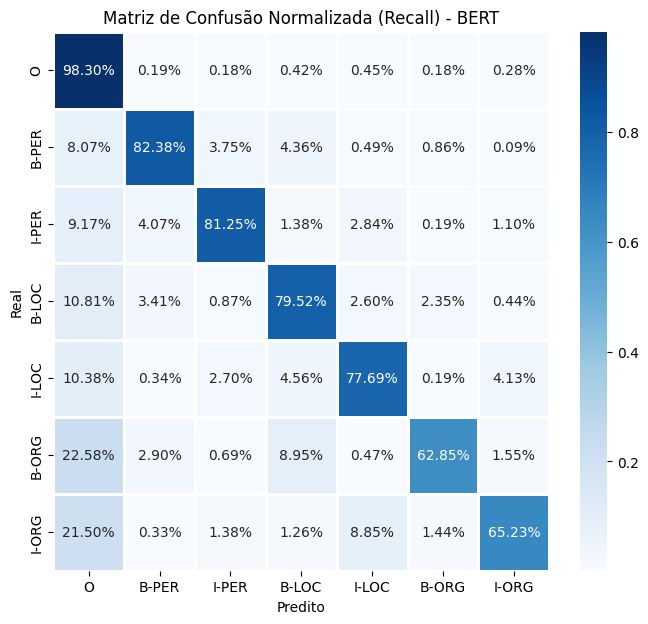

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 7))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            linecolor='white', linewidths=1)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão Normalizada (Recall) - BERT")
plt.show()

### N-gramas + Logistic Regression

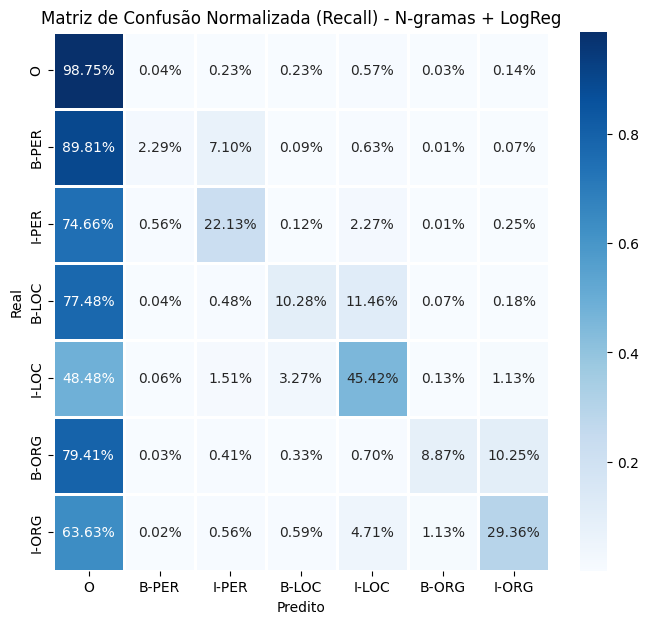

In [ ]:
y_true_flat_ng = [label for doc in y_true_ngrama for label in doc]
y_pred_flat_ng = [label for doc in y_pred_ngrama for label in doc]

labels = list(LABEL2ID.keys())

cm_ng = confusion_matrix(y_true_flat_ng, y_pred_flat_ng, labels=labels)

cm_normalized_ng = cm_ng.astype('float') / cm_ng.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 7))
sns.heatmap(cm_normalized_ng, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            linecolor='white', linewidths=1)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão Normalizada (Recall) - N-gramas + LogReg")
plt.show()

### Baseline Regex

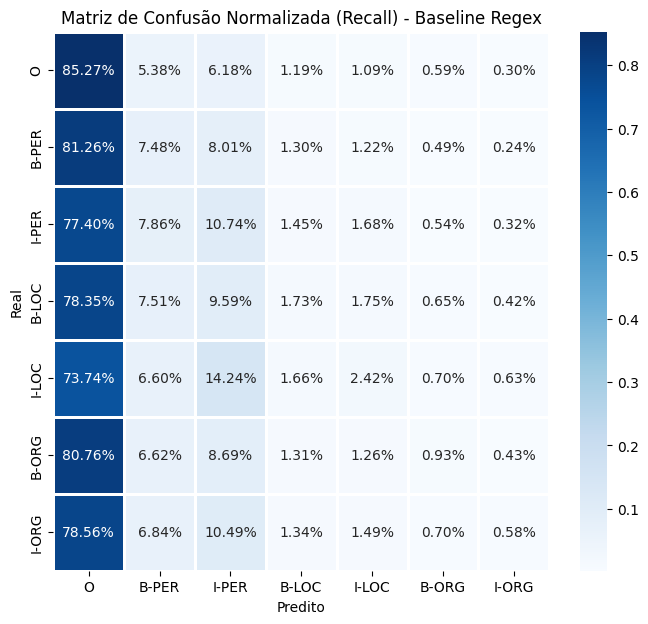

In [ ]:
y_true_flat_regex = [label for doc in y_true_regex for label in doc]
y_pred_flat_regex = [label for doc in y_pred_regex for label in doc]

labels = list(LABEL2ID.keys())

cm_regex = confusion_matrix(y_true_flat_regex, y_pred_flat_regex, labels=labels)

cm_normalized_regex = cm_regex.astype('float') / cm_regex.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 7))
sns.heatmap(cm_normalized_regex, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            linecolor='white', linewidths=1)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão Normalizada (Recall) - Baseline Regex")
plt.show()

## Vantagens e Desvantagens de Cada Abordagem

| Abordagem | Vantagens | Desvantagens |
|-----------|-----------|-------------|
| **Regex** | Interpretável, sem treinamento, rápido, sem dependências | Sem generalização, falsos positivos, manutenção custosa, sem contexto |
| **BoW / TF-IDF** | Simples, eficiente, boa para classificação de documentos | Perde ordem dos tokens, sem semântica, inadequado para NER token-a-token |
| **N-gramas + LogReg** | Captura contexto local, treinável, interpretável | Vocabulário esparso, sem contexto de longo alcance, sem semântica distribucional |
| **BERT** | Embeddings contextuais, estado da arte, generaliza bem | Alto custo computacional, requer GPU, caixa-preta, dados de treino necessários |

### Custo Computacional

| Abordagem | Treino | Inferência | Hardware |
|-----------|--------|------------|----------|
| Regex | Nenhum | < 1s | CPU |
| BoW/TF-IDF | Segundos | < 1s | CPU |
| N-gramas + LogReg | Minutos | Segundos | CPU |
| BERT | 10–60 min | Segundos/GPU | GPU T4 |

### Quando Usar Cada Abordagem

- **Regex:** prototipagem rápida, domínios muito específicos com padrões fixos
- **BoW/TF-IDF:** classificação de documentos (não NER token-a-token)
- **N-gramas:** quando GPU não está disponível e precisão moderada é aceitável
- **BERT:** produção, quando precisão é crítica e GPU está disponível

## Conclusão

### Melhor Abordagem: BERT (BERTimbau)

O modelo `neuralmind/bert-base-portuguese-cased` (BERTimbau) obteve o **maior F1-Score macro** entre todas as abordagens avaliadas, confirmando a superioridade dos modelos baseados em Transformers para NER em português.

### Justificativa Quantitativa

Os resultados da tabela comparativa mostram que o BERT supera as abordagens tradicionais em todas as classes de entidades (PER, LOC, ORG), com ganhos especialmente significativos em:
- **Entidades ambíguas** (ex: "Banco" como organização vs. objeto)
- **Entidades compostas** (ex: "Rio de Janeiro", "Estados Unidos")
- **Contexto de longo alcance** (ex: pronomes que se referem a entidades anteriores)

### Justificativa Qualitativa

O BERT utiliza **embeddings contextuais**: a representação de cada token depende de todos os outros tokens da frase. Isso permite:
1. Distinguir "Banco do Brasil" (ORG) de "banco de madeira" (objeto)
2. Reconhecer entidades nunca vistas no treino por similaridade semântica
3. Capturar dependências de longo alcance entre tokens

### Limitações do Experimento

| Limitação | Impacto |
|-----------|--------|
| **Anotações sintéticas** | O ground truth é gerado por heurísticas, não por anotadores humanos. Métricas refletem o desempenho sobre esse ground truth aproximado, não sobre NER real. |
| **Tamanho do dataset** | 10.000 artigos é pequeno para fine-tuning de BERT. Datasets maiores (ex: WikiNER, HAREM) produziriam resultados mais robustos. |
| **Heurísticas de capitalização** | A anotação sintética introduz viés: tokens capitalizados são frequentemente marcados como PER, mesmo quando são início de frase. |
| **Avaliação no mesmo domínio** | Todos os modelos foram treinados e avaliados em Wikipedia. Desempenho em outros domínios (notícias, redes sociais) pode ser inferior. |

## Testando os Modelos com um Texto Personalizado

In [53]:
texto_exemplo1 = "Bertrand Lira mora na cidade de Joâo Pessoa e estudou na Universidade Federal da Paraíba. Aos 25 anos de idade, ganhou o Prêmio Turing por um software que fazia Reconhecimento de Entidades Nomeadas usando um fine tuning com o modelo BERT. Após isso, foi convidado a ser membro executivo do Google pelo seu grande feito."
texto_exemplo = "Google was founded by Larry Page and Sergey Brin while they were Ph.D. students at Stanford University in California."

print(f"Texto de entrada: {texto_exemplo}\n")

doc_exemplo = nlp.make_doc(texto_exemplo)
tokens_exemplo = [token.text for token in doc_exemplo]
tokens_exemplo = filtrar_tokens_regex_like(tokens_exemplo)

print(f"Tokens processados: {tokens_exemplo}\n")

print("--- Predição do Modelo: Baseline Regex ---")
pred_regex_raw = ner_regex(texto_exemplo)
pred_regex_filtered = [pred for token_orig, pred in pred_regex_raw if token_orig in tokens_exemplo]

print("Token                | Predição Regex")
print("----------------------------------")
for tok, pred in zip(tokens_exemplo, pred_regex_filtered):
    print(f"{tok:20s} | {pred:10s}")


print("\n--- Predição do Modelo: N-gramas + LogReg ---")
X_pred_ng = preparar_features_ngrama([tokens_exemplo])
y_pred_ng_flat = pipeline_ngrama.predict(X_pred_ng)

print("Token                | Predição N-gramas")
print("-----------------------------------")
for tok, pred in zip(tokens_exemplo, y_pred_ng_flat):
    print(f"{tok:20s} | {pred:10s}")


print("\n--- Predição do Modelo: BERT (BERTimbau) ---")
y_pred_bert = predizer_bert_sliding_window(
    [tokens_exemplo],
    trainer,
    tokenizer
)

pred_bert_labels = y_pred_bert[0]

print("Token                | Predição BERT")
print("-----------------------------------")
for tok, pred in zip(tokens_exemplo, pred_bert_labels):
    print(f"{tok:20s} | {pred:20s}")

Texto de entrada: Google was founded by Larry Page and Sergey Brin while they were Ph.D. students at Stanford University in California.

Tokens processados: ['Google', 'was', 'founded', 'by', 'Larry', 'Page', 'and', 'Sergey', 'Brin', 'while', 'they', 'were', 'students', 'at', 'Stanford', 'University', 'in', 'California']

--- Predição do Modelo: Baseline Regex ---
Token                | Predição Regex
----------------------------------
Google               | O         
was                  | O         
founded              | O         
by                   | O         
Larry                | B-PER     
Page                 | I-PER     
and                  | O         
Sergey               | B-PER     
Brin                 | I-PER     
while                | O         
they                 | O         
were                 | O         
students             | O         
at                   | O         
Stanford             | B-PER     
University           | I-PER     
in              

## Salvar modelo

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [29]:
BASE_PATH = "/content/drive/MyDrive/models_ner"

In [30]:
import os
os.makedirs(BASE_PATH, exist_ok=True)

In [31]:
#Salvar bert
BERT_PATH = f"{BASE_PATH}/bert_ner"

trainer.save_model(BERT_PATH)
tokenizer.save_pretrained(BERT_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/models_ner/bert_ner/tokenizer_config.json',
 '/content/drive/MyDrive/models_ner/bert_ner/tokenizer.json')

In [34]:
#Salvar n-gramas
import joblib

NGRAM_PATH = f"{BASE_PATH}/ngram_model.pkl"

joblib.dump({
    "vectorizer": TfidfVectorizer,
    "model": LogisticRegression
}, NGRAM_PATH)

['/content/drive/MyDrive/models_ner/ngram_model.pkl']